In [2]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

In [56]:
import pandas as pd
import numpy as np
import seaborn as sns
from dotenv import load_dotenv
import os
from ConfigSpace.read_and_write import pcs_new
import wandb
load_dotenv()

True

In [8]:
casmo_table = pd.read_csv("distance_data/wandb_export_2026-03-18T15_38_29.970+01_00.csv")
# casmo_configspace =

In [57]:
run = wandb.init(project="Styx", job_type="read-table")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/skippybal/.netrc.
wandb: Currently logged in as: knotebomer (knotebomer-leiden-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [59]:
artifact = run.use_artifact("/Styx/run-7a1mmyef-all_X:latest", type="run_table")

In [64]:
table = artifact.get("all_X")
# Now you can use the table, for example converting to a pandas dataframe
casmo_table = table.get_dataframe()
# print(df.head())

wandb:   1 of 1 files downloaded.  


In [65]:
param_file_loc = os.getenv('PARAM_FILE_LOC')
    # load_dotenv()
    # breakpoint()
with open(param_file_loc, 'r') as fh:
    casmo_configspace = pcs_new.read(fh)
casmo_configspace.seed(721)
print(casmo_configspace)

/tmp/ipykernel_84679/4008333141.py:5: DeprecationWarning: pcs_new.read is has stopped being maintained, please use `space.to_json` or `space.to_yaml` instead
  casmo_configspace = pcs_new.read(fh)


Configuration space object:
  Hyperparameters:
    aggfill, Type: UniformInteger, Range: [1, 2048], Default: 1024
    aggregate, Type: Categorical, Choices: {0, 1}, Default: 1
    auto_aggfill_on, Type: Categorical, Choices: {0, 1}, Default: 1
    auto_barcorrectors, Type: Categorical, Choices: {0, 1}, Default: 1
    auto_barhomogeneous, Type: Categorical, Choices: {0, 1}, Default: 1
    auto_barorder, Type: Categorical, Choices: {0, 1}, Default: 1
    auto_bqpcuts_on, Type: Categorical, Choices: {0, 1}, Default: 1
    auto_branchdir_on, Type: Categorical, Choices: {0, 1}, Default: 1
    auto_cliquecuts_on, Type: Categorical, Choices: {0, 1}, Default: 1
    auto_covercuts_on, Type: Categorical, Choices: {0, 1}, Default: 1
    auto_crossover, Type: Categorical, Choices: {0, 1}, Default: 1
    auto_cutaggpasses_on, Type: Categorical, Choices: {0, 1}, Default: 1
    auto_cutpasses_on, Type: Categorical, Choices: {0, 1}, Default: 1
    auto_cuts_on, Type: Categorical, Choices: {0, 1}, Defa

In [15]:
import ConfigSpace.hyperparameters.categorical
cont_names = set()
cat_names = set()

int_names = []
#TODO: make a default section here? can just get from configspace as well i think

# print(dict(deserialized_conf))
for index, (name, obj) in enumerate(dict(casmo_configspace).items()):

    if type(obj) == ConfigSpace.hyperparameters.categorical.CategoricalHyperparameter:

        cat_names.add(name)

    elif type(obj) == ConfigSpace.hyperparameters.uniform_integer.UniformIntegerHyperparameter:
        cont_names.add(name)

    elif type(obj) == ConfigSpace.hyperparameters.uniform_float.UniformFloatHyperparameter:
        cont_names.add(name)

    else:
        print(f"unknown: {obj}")

print(cont_names)
print(cat_names)


{'cutaggpasses', 'gubcovercuts', 'impliedcuts', 'mipsepcuts', 'infproofcuts', 'rltcuts', 'heuristics', 'improvestarttime', 'improvestartnodes', 'disconnected', 'relaxliftcuts', 'prepasses', 'flowcovercuts', 'zerohalfcuts', 'strongcgcuts', 'gomorypasses', 'mircuts', 'symmetry', 'submipnodes', 'covercuts', 'pumppasses', 'submipcuts', 'projimpliedcuts', 'startnodelimit', 'zeroobjnodes', 'aggfill', 'bqpcuts', 'flowpathcuts', 'minrelnodes', 'modkcuts', 'rins', 'networkcuts', 'degenmoves', 'barcorrectors', 'cuts', 'perturbvalue', 'cutpasses', 'sifting', 'presolve', 'cliquecuts', 'improvestartgap'}
{'auto_networkcuts_on', 'auto_nodemethod_on', 'auto_presolve_on', 'aggregate', 'auto_pumppasses_on', 'mipfocus', 'auto_modkcuts_on', 'auto_prepasses_on', 'predeprow', 'presparsify', 'auto_cutaggpasses_on', 'auto_mircuts_on', 'partitionplace', 'simplexpricing', 'varbranch', 'nodemethod', 'auto_relaxliftcuts_on', 'auto_barhomogeneous', 'auto_zeroobjnodes_on', 'crossover', 'auto_gomorypasses_on', 'qua

In [ ]:
# TODO: how are we going to deal with the continuous ones that are dependen on the other? dist to defualt?

In [35]:
def build_manhatten_dist_mat(configspace, config_table, cat_names, cont_names):
    print(len(config_table))
    dists = np.zeros((len(config_table), len(config_table)))
    print(dists.shape)
    for i in range(dists.shape[0]):
        for j in range(i, dists.shape[1]):
            # print(config_table.iloc[i])
            # print(config_table.iloc[i]["auto_issmethod_on"])
            # print(config_table.iloc[i]["auto_barhomogeneous"])
            # print(config_table.iloc[j]["auto_barhomogeneous"])

            for cat_var in cat_names:
                if config_table.iloc[i][cat_var] != config_table.iloc[j][cat_var]:
                    # print("different")
                    # print(config_table.iloc[i][cat_var])
                    # print(config_table.iloc[j][cat_var])
                    dists[i,j] += 1
    return dists


casmo_hat_dist = build_manhatten_dist_mat(casmo_configspace, casmo_table, cat_names, cont_names)
print(casmo_hat_dist)

45
(45, 45)
[[ 0. 37. 44. ... 40. 39. 40.]
 [ 0.  0. 39. ... 32. 34. 34.]
 [ 0.  0.  0. ... 42. 43. 43.]
 ...
 [ 0.  0.  0. ...  0.  5.  3.]
 [ 0.  0.  0. ...  0.  0.  4.]
 [ 0.  0.  0. ...  0.  0.  0.]]


<Axes: >

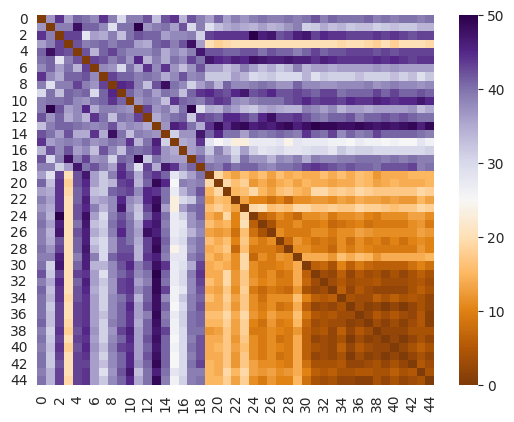

In [40]:
sns.heatmap(casmo_hat_dist + casmo_hat_dist.T, cmap="PuOr")

In [17]:
# casmo_hat_dist = build_manhatten_dist_mat(casmo_configspace, casmo_table, cat_names, cont_names)

45


In [66]:
def build_euc_dist_mat(configspace, config_table, cat_names, cont_names):
    print(len(config_table))
    dists = np.zeros((len(config_table), len(config_table)))
    print(dists.shape)
    for i in range(dists.shape[0]):
        for j in range(i, dists.shape[1]):
            # print(config_table.iloc[i])
            # print(config_table.iloc[i]["auto_issmethod_on"])
            # print(config_table.iloc[i]["auto_barhomogeneous"])
            # print(config_table.iloc[j]["auto_barhomogeneous"])

            for con_var in cont_names:
                # if config_table.iloc[i][con_var] != config_table.iloc[j][con_var]:
                #     # print("different")
                try:
                    # print(con_var)
                    # print(config_table.iloc[i][con_var])
                    # print(config_table.iloc[j][con_var])
                    dists[i,j] += (config_table.iloc[i][con_var] - config_table.iloc[j][con_var]) ** 2
                except Exception as e:
                    print(e)
                    print(f"Variable not found?: {con_var}")


                # dists[i,j] += (config_table.iloc[i][con_var] - config_table.iloc[j][con_var]) ** 2
    return np.sqrt(dists)

In [67]:
print(casmo_table.columns)
print(len(casmo_table.columns))
print(len(cat_names))
print(len(cont_names))

Index(['run_id', 'aggregate', 'auto_aggfill_on', 'auto_barcorrectors',
       'auto_barhomogeneous', 'auto_barorder', 'auto_bqpcuts_on',
       'auto_branchdir_on', 'auto_cliquecuts_on', 'auto_covercuts_on',
       ...
       'relaxliftcuts', 'rins', 'rltcuts', 'sifting', 'startnodelimit',
       'strongcgcuts', 'submipcuts', 'symmetry', 'zerohalfcuts',
       'zeroobjnodes'],
      dtype='object', length=112)
112
70
41


The table is 11 variables shorter then it should be.... and it's exatctely the ones we seem to be missing

In [68]:
casmo_euc_dist = build_euc_dist_mat(casmo_configspace, casmo_table, cat_names, cont_names)
print(casmo_euc_dist)

45
(45, 45)
[[      0.         2301597.99657463 2397939.59529362 ... 1688707.05190443
  2316083.86184002 1136660.3516951 ]
 [      0.               0.         2611067.64677163 ... 2061765.7770203
  1635905.81522794 2197643.04622323]
 [      0.               0.               0.         ... 1846043.32616649
  1945180.23929376 2696518.4005093 ]
 ...
 [      0.               0.               0.         ...       0.
  1654396.923567   1274345.10570995]
 [      0.               0.               0.         ...       0.
        0.         2358215.8960321 ]
 [      0.               0.               0.         ...       0.
        0.               0.        ]]


<Axes: >

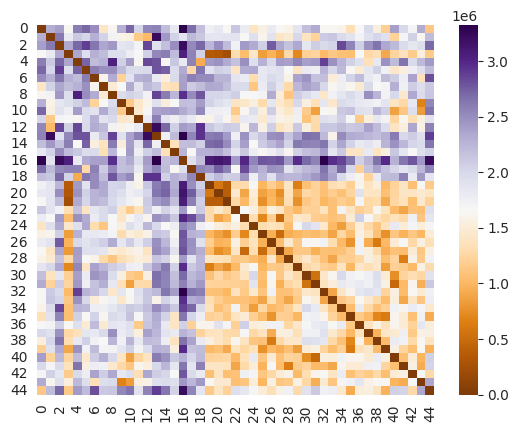

In [70]:
sns.heatmap(casmo_euc_dist + casmo_euc_dist.T, cmap="PuOr")

<Axes: >

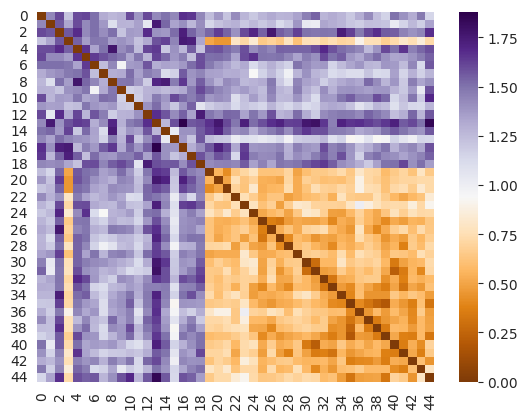

In [72]:
full_euc = casmo_euc_dist + casmo_euc_dist.T
full_hat = casmo_hat_dist + casmo_hat_dist.T

normal_euc = (full_euc - np.min(full_euc)) / (np.max(full_euc) - np.min(full_euc))
normal_hat = (full_hat - np.min(full_hat)) / (np.max(full_hat) - np.min(full_hat))
sns.heatmap(normal_euc + normal_hat, cmap="PuOr")